In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sushmi17/customer-churn-prediction-dataset/Churn_Modelling.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/sushmi17/customer-churn-prediction-dataset/Churn_Modelling.csv"
)

# Display first 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (10000, 14)

Column Names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data Types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

First 5 Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Check missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [5]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [6]:
# Target variable distribution
print("Exited Value Counts:")
print(df["Exited"].value_counts())

print("\nExited Percentage:")
print(df["Exited"].value_counts(normalize=True) * 100)

Exited Value Counts:
Exited
0    7963
1    2037
Name: count, dtype: int64

Exited Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


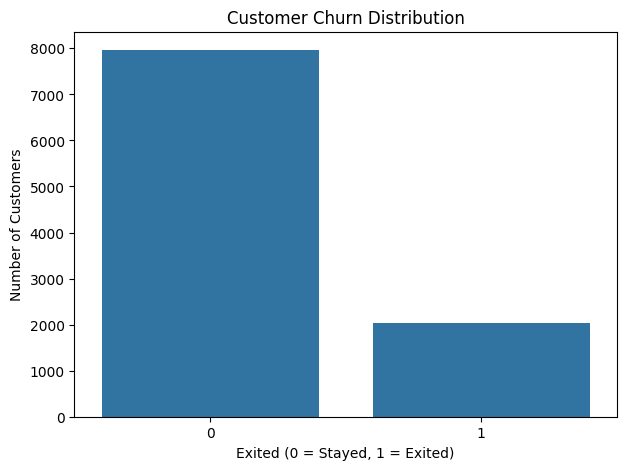

In [7]:
# Target distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Exited")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Exited)")
plt.ylabel("Number of Customers")

plt.show()

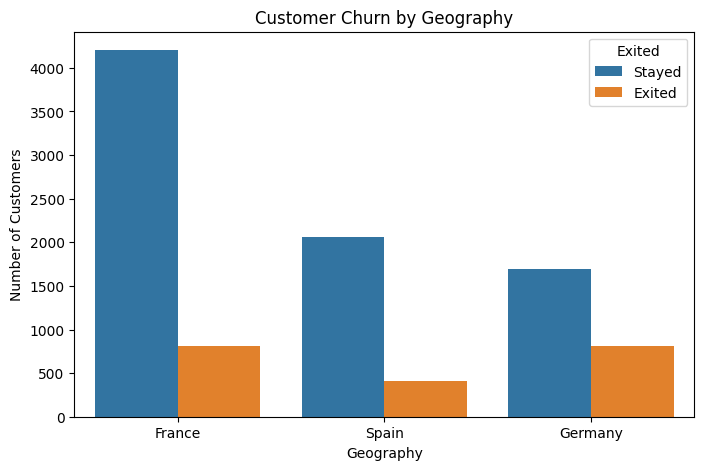

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Geography", hue="Exited")

plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Stayed", "Exited"])

plt.show()

In [9]:
# Calculate churn rate by geography
geography_churn = df.groupby("Geography")["Exited"].mean() * 100

print("Churn Rate by Geography:")
print(geography_churn)

Churn Rate by Geography:
Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


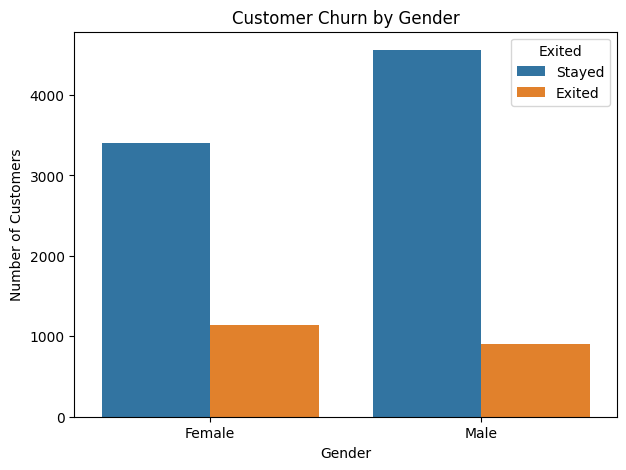

In [10]:
# Customer churn by gender
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Gender", hue="Exited")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Stayed", "Exited"])

plt.show()

In [11]:
# Calculate churn rate by gender
gender_churn = df.groupby("Gender")["Exited"].mean() * 100

print("Churn Rate by Gender:")
print(gender_churn)

Churn Rate by Gender:
Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


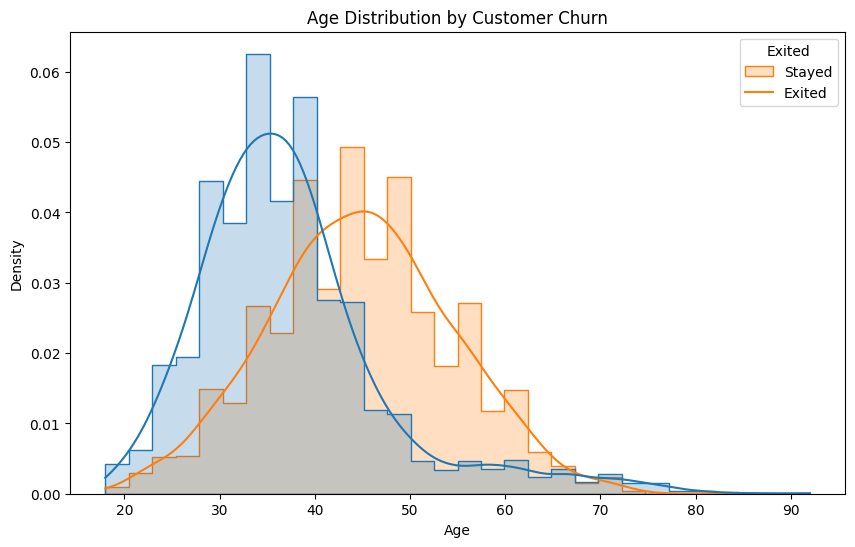

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    hue="Exited",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Age Distribution by Customer Churn")
plt.xlabel("Age")
plt.ylabel("Density")

plt.legend(title="Exited", labels=["Stayed", "Exited"])

plt.show()

In [13]:
# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

# Calculate churn rate for each age group
age_churn = df.groupby("AgeGroup", observed=False)["Exited"].mean() * 100

print("Churn Rate by Age Group:")
print(age_churn)

Churn Rate by Age Group:
AgeGroup
18-30     7.520325
31-40    12.087171
41-50    33.965517
51-60    56.210790
60+      24.784483
Name: Exited, dtype: float64


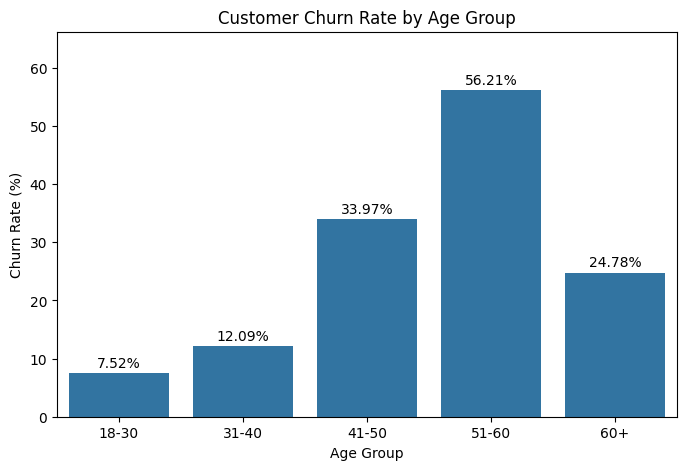

In [14]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=age_churn.index,
    y=age_churn.values
)

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(age_churn.values):
    ax.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.ylim(0, max(age_churn.values) + 10)

plt.show()

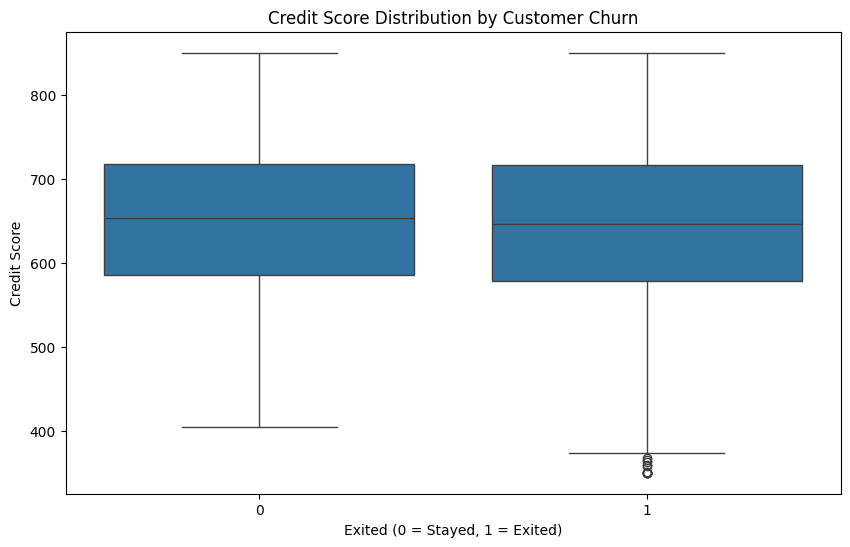

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Exited",
    y="CreditScore"
)

plt.title("Credit Score Distribution by Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Exited)")
plt.ylabel("Credit Score")

plt.show()

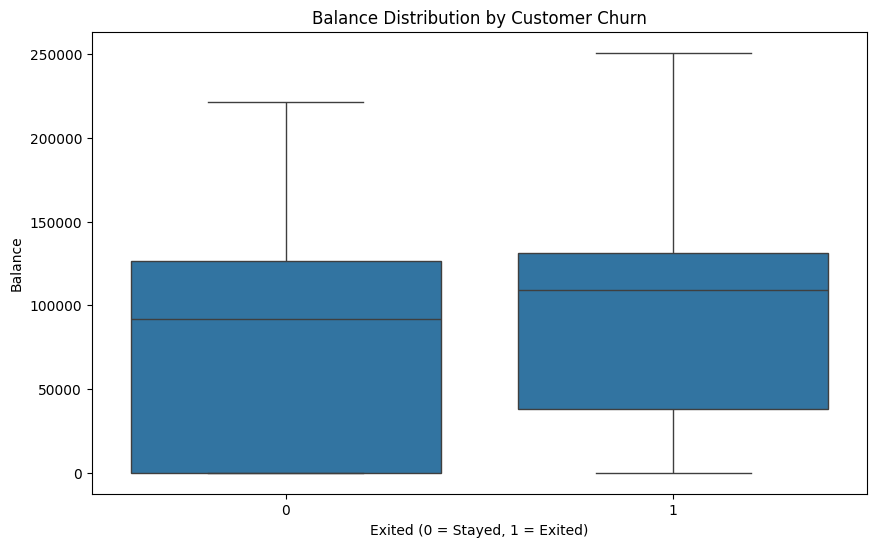

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Exited",
    y="Balance"
)

plt.title("Balance Distribution by Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Exited)")
plt.ylabel("Balance")

plt.show()

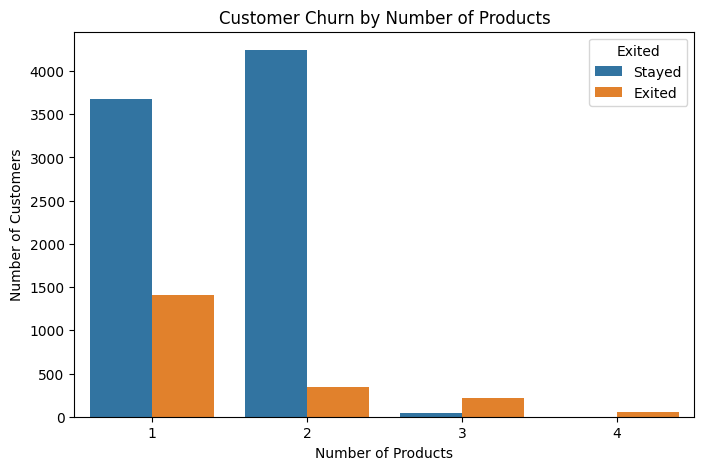

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="NumOfProducts",
    hue="Exited"
)

plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Stayed", "Exited"])

plt.show()

In [18]:
# Calculate churn rate by number of products
product_churn = df.groupby("NumOfProducts")["Exited"].mean() * 100

print("Churn Rate by Number of Products:")
print(product_churn)

Churn Rate by Number of Products:
NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


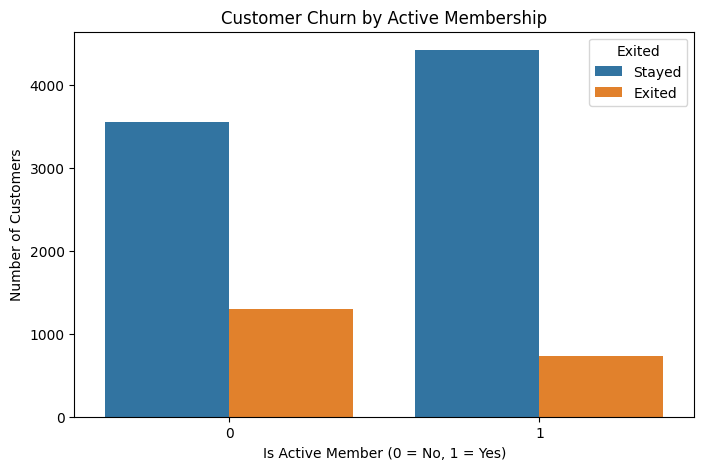

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="IsActiveMember",
    hue="Exited"
)

plt.title("Customer Churn by Active Membership")
plt.xlabel("Is Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Stayed", "Exited"])

plt.show()

In [20]:
active_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100

print("Churn Rate by Active Membership:")
print(active_churn)

Churn Rate by Active Membership:
IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [21]:
tenure_churn = df.groupby("Tenure")["Exited"].mean() * 100

print("Churn Rate by Tenure:")
print(tenure_churn)

Churn Rate by Tenure:
Tenure
0     23.002421
1     22.415459
2     19.179389
3     21.110010
4     20.525784
5     20.652174
6     20.268873
7     17.217899
8     19.219512
9     21.646341
10    20.612245
Name: Exited, dtype: float64


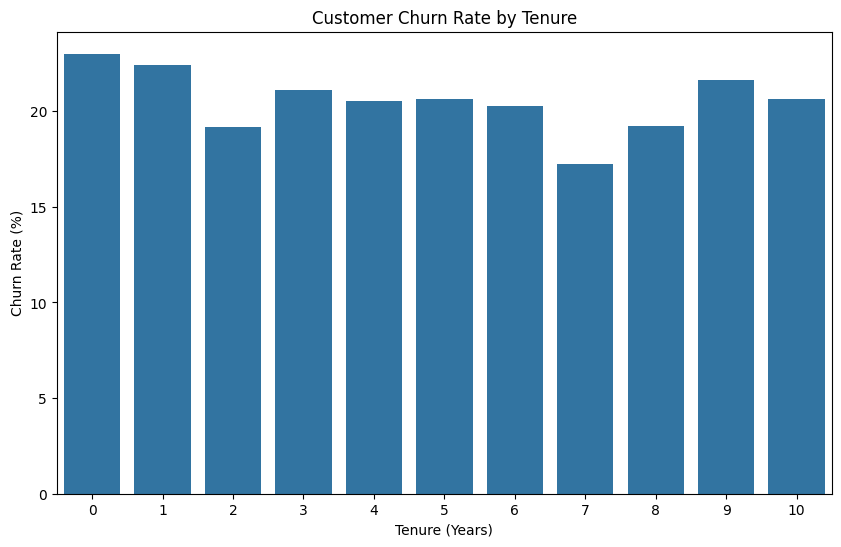

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Customer Churn Rate by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")

plt.show()

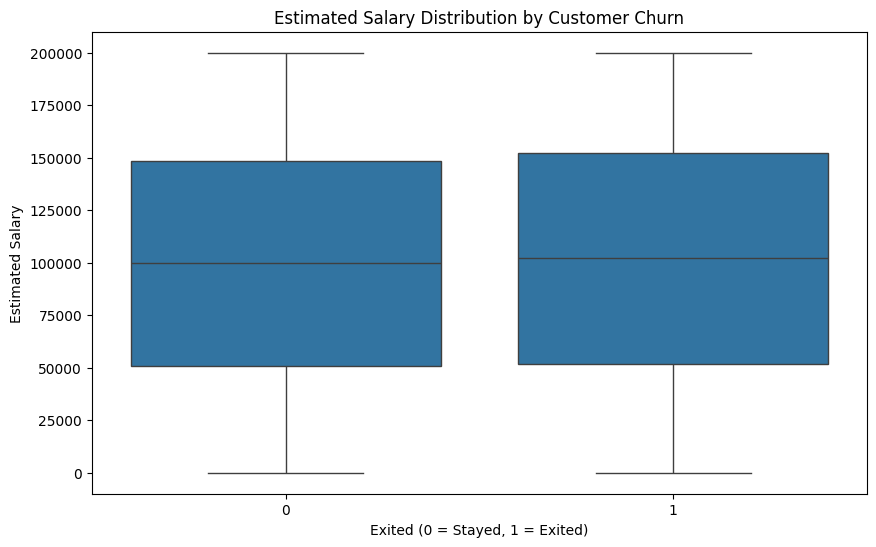

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Exited",
    y="EstimatedSalary"
)

plt.title("Estimated Salary Distribution by Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Exited)")
plt.ylabel("Estimated Salary")

plt.show()

In [24]:
salary_summary = df.groupby("Exited")["EstimatedSalary"].agg(
    ["mean", "median", "std"]
)

print("Estimated Salary Summary by Churn:")
print(salary_summary)

Estimated Salary Summary by Churn:
                 mean     median           std
Exited                                        
0        99738.391772   99645.04  57405.586966
1       101465.677531  102460.84  57912.418071


In [25]:
# Select numerical columns for correlation analysis

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited"
]

correlation_matrix = df[numerical_features].corr()

print(correlation_matrix["Exited"].sort_values(ascending=False))

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


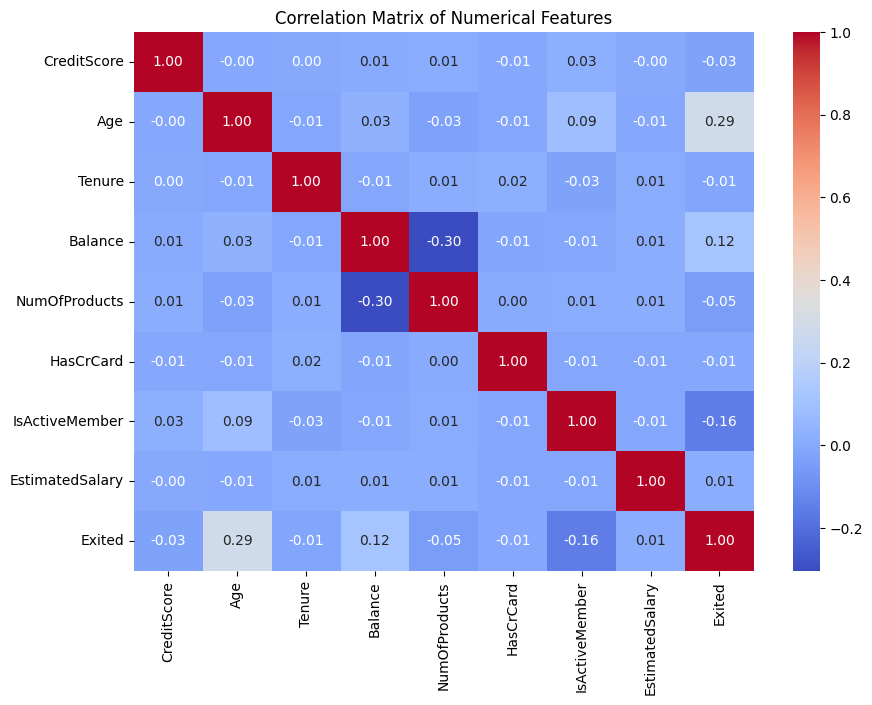

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [27]:
# Remove identifier and non-predictive columns

df_model = df.drop(
    columns=["RowNumber", "CustomerId", "Surname"]
)

print("Shape after removing unnecessary columns:", df_model.shape)
print("\nRemaining columns:")
print(df_model.columns.tolist())

Shape after removing unnecessary columns: (10000, 12)

Remaining columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'AgeGroup']


In [28]:
# Remove derived AgeGroup feature
# Age itself will be used by the Decision Tree

df_model = df_model.drop(columns=["AgeGroup"])

print("Shape after removing AgeGroup:", df_model.shape)

print("\nFinal columns:")
print(df_model.columns.tolist())

Shape after removing AgeGroup: (10000, 11)

Final columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [29]:
# Define features and target

X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (10000, 10)
y shape: (10000,)

Feature columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Separate categorical and numerical features
categorical_features = ['Geography', 'Gender']

numerical_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary'
]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# One-Hot Encoding for categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features)
    ],
    remainder='passthrough'
)

# Transform training and testing data
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("\nEncoded X_train shape:", X_train_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)

X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)

Encoded X_train shape: (8000, 13)
Encoded X_test shape: (2000, 13)


In [31]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train_encoded, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [32]:
# Make predictions on test data

y_pred = dt_model.predict(X_test_encoded)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions generated successfully!
Number of predictions: 2000

First 10 Predictions:
[0 0 0 0 0 0 0 0 1 0]


In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Decision Tree Accuracy: {accuracy:.4f}")
print(f"Decision Tree Accuracy: {accuracy * 100:.2f}%")

Decision Tree Accuracy: 0.7935
Decision Tree Accuracy: 79.35%


Confusion Matrix:
[[1377  216]
 [ 197  210]]


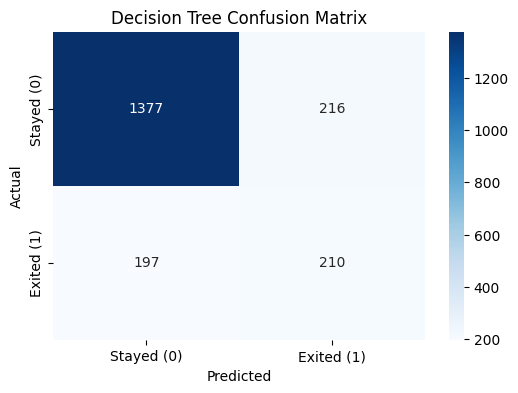

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed (0)', 'Exited (1)'],
    yticklabels=['Stayed (0)', 'Exited (1)']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=["Stayed (0)", "Exited (1)"]
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.86      0.87      1593
  Exited (1)       0.49      0.52      0.50       407

    accuracy                           0.79      2000
   macro avg       0.68      0.69      0.69      2000
weighted avg       0.80      0.79      0.80      2000



In [36]:
from sklearn.metrics import roc_auc_score

# Get probability predictions for the positive class
y_prob = dt_model.predict_proba(X_test_encoded)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Decision Tree ROC-AUC: {roc_auc:.4f}")
print(f"Decision Tree ROC-AUC: {roc_auc:.2f}")

Decision Tree ROC-AUC: 0.6902
Decision Tree ROC-AUC: 0.69


In [37]:
# Get feature names after One-Hot Encoding

feature_names = preprocessor.get_feature_names_out()

# Get feature importance
feature_importance = dt_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                           Feature  Importance
6                   remainder__Age    0.224765
8               remainder__Balance    0.154524
12      remainder__EstimatedSalary    0.153597
5           remainder__CreditScore    0.138301
9         remainder__NumOfProducts    0.117425
7                remainder__Tenure    0.072372
11       remainder__IsActiveMember    0.057558
1   categorical__Geography_Germany    0.022347
10            remainder__HasCrCard    0.017117
4         categorical__Gender_Male    0.014700
3       categorical__Gender_Female    0.012167
0    categorical__Geography_France    0.009421
2     categorical__Geography_Spain    0.005706


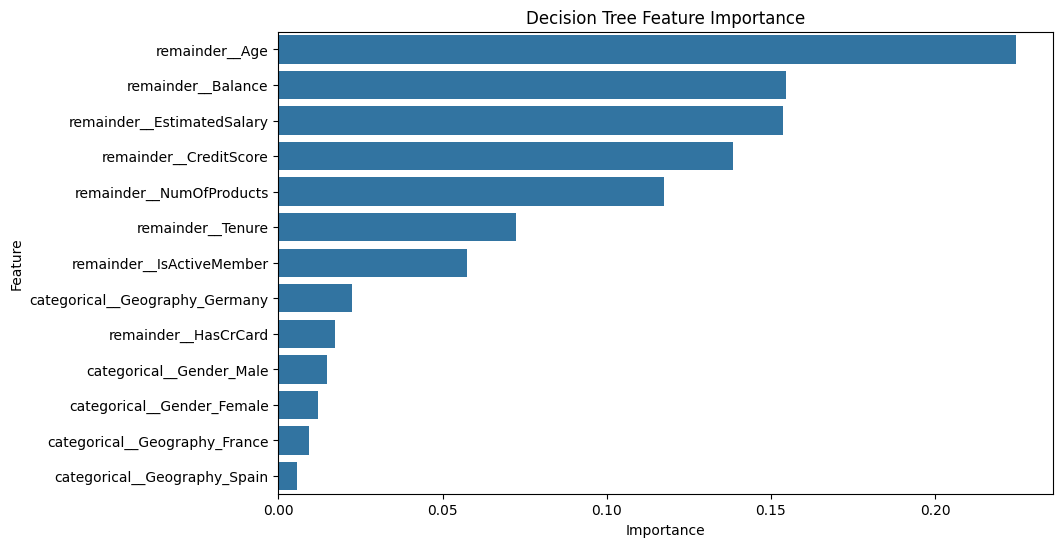

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

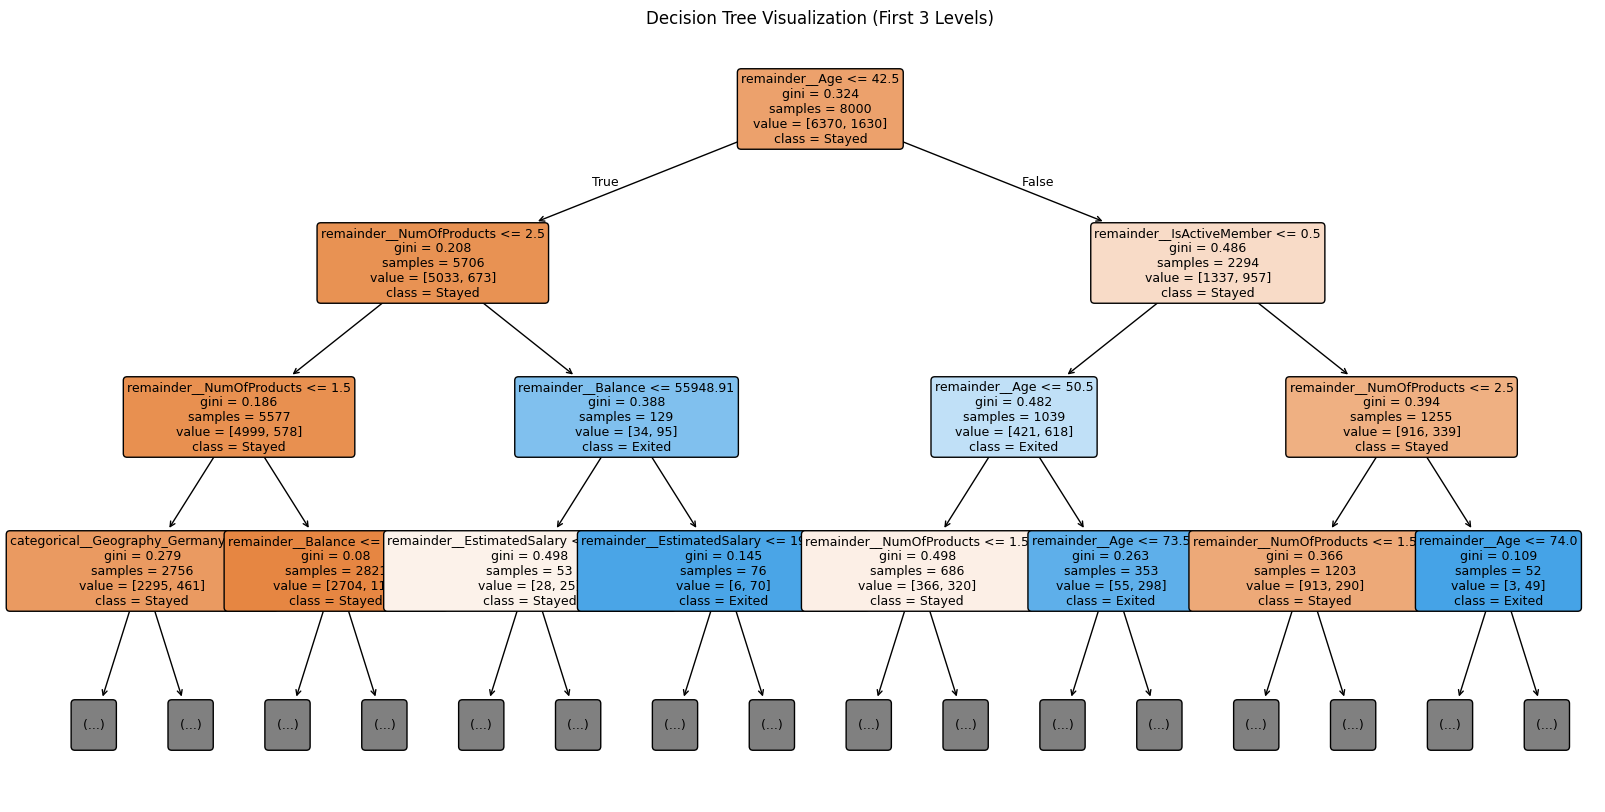

In [39]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    max_depth=3,
    feature_names=feature_names,
    class_names=["Stayed", "Exited"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

In [40]:
from sklearn.tree import DecisionTreeClassifier

dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_tuned.fit(X_train_encoded, y_train)

print("Tuned Decision Tree trained successfully!")

Tuned Decision Tree trained successfully!


In [41]:
# Predictions using tuned Decision Tree

y_pred_tuned = dt_tuned.predict(X_test_encoded)

print("Tuned model predictions generated successfully!")
print("Number of predictions:", len(y_pred_tuned))

print("\nFirst 10 Predictions:")
print(y_pred_tuned[:10])

Tuned model predictions generated successfully!
Number of predictions: 2000

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]


In [42]:
from sklearn.metrics import accuracy_score

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Decision Tree Accuracy: {tuned_accuracy:.4f}")
print(f"Tuned Decision Tree Accuracy: {tuned_accuracy * 100:.2f}%")

Tuned Decision Tree Accuracy: 0.8560
Tuned Decision Tree Accuracy: 85.60%


In [43]:
from sklearn.metrics import classification_report

tuned_report = classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Stayed (0)", "Exited (1)"]
)

print("Tuned Decision Tree Classification Report:")
print(tuned_report)

Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.86      0.97      0.91      1593
  Exited (1)       0.79      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000



In [44]:
from sklearn.metrics import roc_auc_score

# Probability predictions for Exited class
y_prob_tuned = dt_tuned.predict_proba(X_test_encoded)[:, 1]

# Calculate ROC-AUC
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)

print(f"Tuned Decision Tree ROC-AUC: {tuned_roc_auc:.4f}")
print(f"Tuned Decision Tree ROC-AUC: {tuned_roc_auc:.2f}")

Tuned Decision Tree ROC-AUC: 0.8433
Tuned Decision Tree ROC-AUC: 0.84


In [45]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Exited Precision",
        "Exited Recall",
        "Exited F1-Score",
        "ROC-AUC"
    ],
    "Baseline Decision Tree": [
        accuracy,
        0.49,
        0.52,
        0.50,
        roc_auc
    ],
    "Tuned Decision Tree": [
        tuned_accuracy,
        0.79,
        0.40,
        0.53,
        tuned_roc_auc
    ]
})

comparison

,Metric,Baseline Decision Tree,Tuned Decision Tree
0,Accuracy,0.793500,0.856000
1,Exited Precision,0.490000,0.790000
2,Exited Recall,0.520000,0.400000
3,Exited F1-Score,0.500000,0.530000
4,ROC-AUC,0.690189,0.843269


Tuned Decision Tree Confusion Matrix:
[[1549   44]
 [ 244  163]]


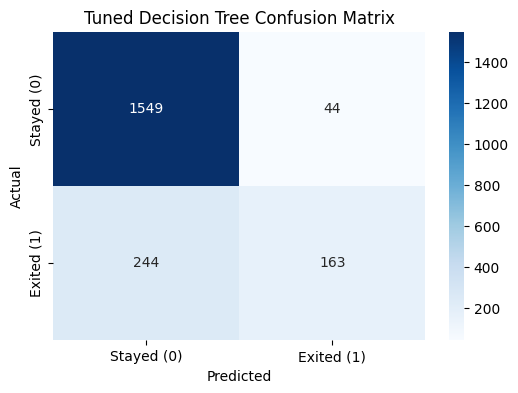

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Tuned Decision Tree Confusion Matrix:")
print(cm_tuned)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed (0)', 'Exited (1)'],
    yticklabels=['Stayed (0)', 'Exited (1)']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Decision Tree Confusion Matrix")
plt.show()

In [47]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    dt_tuned,
    X_train_encoded,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("5-Fold Cross-Validation ROC-AUC Scores:", cv_scores)
print("Mean Cross-Validation ROC-AUC:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

5-Fold Cross-Validation ROC-AUC Scores: [0.83638798 0.84052691 0.80612486 0.8343474  0.84663419]
Mean Cross-Validation ROC-AUC: 0.8328042684747329
Standard Deviation: 0.013985144449711611
